<a href="https://colab.research.google.com/github/3Frank3/Diabetes-Risk-Prediction-Fairness-Evaluation-and-Causal-Analysis-of-Physical-Activity-Using-PSM/blob/Jolly/02_Modeling%2B%20ANN%20Model%201%20%2B%20Model%202%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##02_Modeling

# Load Data

In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd

from ucimlrepo import fetch_ucirepo


# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

df = X.copy()
df["Diabetes_binary"] = y.values

# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

Check the dataset

In [3]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-n

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


In [4]:
df["Diabetes_binary"].value_counts(normalize=True)

Diabetes_binary
0    0.860667
1    0.139333
Name: proportion, dtype: float64

Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

# First split: train+val and test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Second split: train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,   # 0.25 of 80% = 20%
    stratify=y_train_val,
    random_state=42
)
print(X_train.shape, X_val.shape, X_test.shape)

(152208, 21) (50736, 21) (50736, 21)


In [35]:
split_summary = pd.DataFrame({
    "Split": ["Training", "Validation", "Test"],
    "Purpose": [
        "Model fitting",
        "Hyperparameter tuning / early stopping",
        "Final evaluation"
    ],
    "Sample Size": [
        len(y_train),
        len(y_val),
        len(y_test)
    ],
    "Diabetes = 1 (%)": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100
    ],
    "Diabetes = 0 (%)": [
        (1 - y_train.mean()) * 100,
        (1 - y_val.mean()) * 100,
        (1 - y_test.mean()) * 100
    ]
})

split_summary.round(2)

,Split,Purpose,Sample Size,Diabetes = 1 (%),Diabetes = 0 (%)
0,Training,Model fitting,152208,13.93,86.07
1,Validation,Hyperparameter tuning / early stopping,50736,13.93,86.07
2,Test,Final evaluation,50736,13.93,86.07


## Feature scaling (standardization)

Scaling standardizes features so that variables with larger values don’t dominate the model.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##LogisticRegression

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score,
    brier_score_loss, average_precision_score
)

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))
print("PR AUC:", average_precision_score(y_test, y_prob_lr))
print("Brier Score:", brier_score_loss(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       0.95      0.73      0.82     43667
           1       0.31      0.76      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.73      0.77     50736

Accuracy: 0.7317486597287922
ROC AUC: 0.8196548264814243
PR AUC: 0.3925124479573125
Brier Score: 0.17736265863982573


##Random Forest

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score,
    brier_score_loss, average_precision_score
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

threshold = 0.15
y_pred_rf = (y_prob_rf >= threshold).astype(int)

print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR AUC:", average_precision_score(y_test, y_prob_rf))
print("Brier Score:", brier_score_loss(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.94      0.71      0.81     43667
           1       0.29      0.74      0.42      7069

    accuracy                           0.71     50736
   macro avg       0.62      0.72      0.61     50736
weighted avg       0.85      0.71      0.76     50736

Accuracy: 0.714660201829076
ROC AUC: 0.7953789148906802
PR AUC: 0.3580985238659691
Brier Score: 0.10396431090150939


##XG Boost

In [9]:
!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score,
    brier_score_loss, average_precision_score
)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

threshold = 0.15
y_pred_xgb = (y_prob_xgb >= threshold).astype(int)

print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))
print("PR AUC:", average_precision_score(y_test, y_prob_xgb))
print("Brier Score:", brier_score_loss(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.95      0.73      0.83     43667
           1       0.32      0.77      0.45      7069

    accuracy                           0.74     50736
   macro avg       0.63      0.75      0.64     50736
weighted avg       0.86      0.74      0.78     50736

Accuracy: 0.7382923368022706
ROC AUC: 0.8269241354557275
PR AUC: 0.42325028312249013
Brier Score: 0.09743125698337055


In [10]:
import pandas as pd

importance_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance_table = (
    importance_table
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

importance_table["Importance"] = importance_table["Importance"].round(4)

importance_table

,Feature,Importance
0,HighBP,0.4829
1,GenHlth,0.1350
2,HighChol,0.0852
3,DiffWalk,0.0540
4,BMI,0.0434
5,Age,0.0403
6,HeartDiseaseorAttack,0.0314
7,HvyAlcoholConsump,0.0284
8,CholCheck,0.0235
9,Income,0.0154


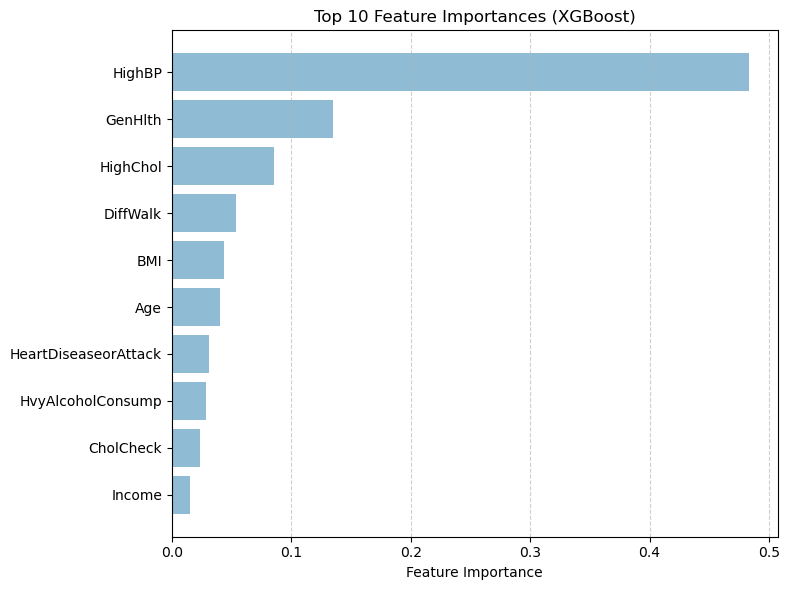

In [11]:
import matplotlib.pyplot as plt

# get importance table (if not already done)
import pandas as pd
importance_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# select top 10 features
top_n = 10
top_features = importance_table.head(top_n)

# plot
plt.figure(figsize=(8,6))

plt.barh(top_features["Feature"], top_features["Importance"], color="#8FBCD4")

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances (XGBoost)")

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Result

In [12]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score, roc_auc_score, brier_score_loss,
    recall_score, precision_score, f1_score,
    average_precision_score
)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "ROC AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],

    "PR AUC": [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb)
    ],

    "Recall (Diabetes=1)": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    "Precision (Diabetes=1)": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    "F1-score (Diabetes=1)": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    "Brier Score": [
        brier_score_loss(y_test, y_prob_lr),
        brier_score_loss(y_test, y_prob_rf),
        brier_score_loss(y_test, y_prob_xgb)
    ]
})

results = results.round(3)

results

,Model,Accuracy,ROC AUC,PR AUC,Recall (Diabetes=1),Precision (Diabetes=1),F1-score (Diabetes=1),Brier Score
0,Logistic Regression,0.732,0.820,0.393,0.760,0.311,0.441,0.177
1,Random Forest,0.715,0.795,0.358,0.738,0.292,0.419,0.104
2,XGBoost,0.738,0.827,0.423,0.768,0.318,0.450,0.097


XGBoost,Random Forest,Logistic Regression   PR Curve

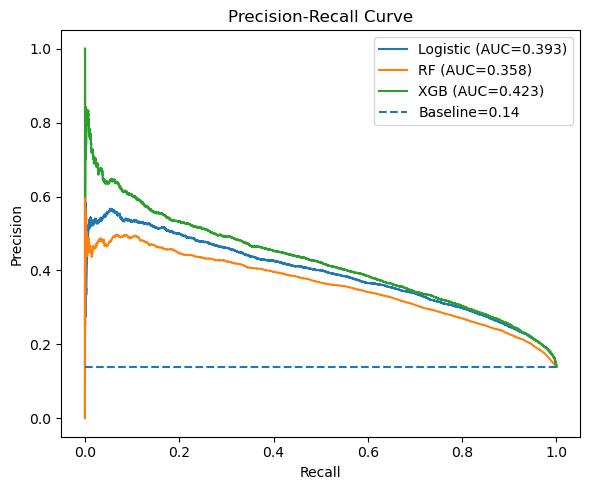

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(6,5))

# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
plt.plot(recall_lr, precision_lr, label=f"Logistic (AUC={average_precision_score(y_test, y_prob_lr):.3f})")

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
plt.plot(recall_rf, precision_rf, label=f"RF (AUC={average_precision_score(y_test, y_prob_rf):.3f})")

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
plt.plot(recall_xgb, precision_xgb, label=f"XGB (AUC={average_precision_score(y_test, y_prob_xgb):.3f})")

# baseline
baseline = y_test.mean()
plt.hlines(baseline, 0, 1, linestyles='dashed', label=f"Baseline={baseline:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()

plt.show()

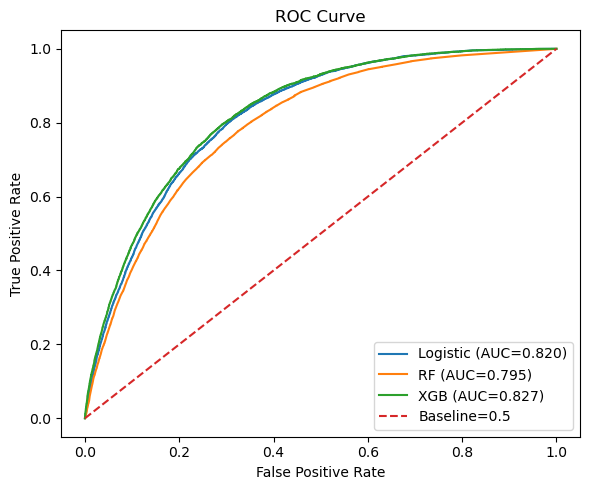

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(6,5))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC={roc_auc_score(y_test, y_prob_lr):.3f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={roc_auc_score(y_test, y_prob_rf):.3f})")

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})")

# baseline (random guess)
plt.plot([0, 1], [0, 1], linestyle='--', label="Baseline=0.5")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()

plt.show()

# Artificial Neural Network (ANN)

In [15]:
# ANN Model 1: Complete Pipeline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve
)

2026-06-08 12:24:49.177076: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [16]:
# 1. Initial ANN Model

ann_model1 = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann_model1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# 2. Train Model

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history1 = ann_model1.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 3s 608us/step - accuracy: 0.8601 - loss: 0.3240 - val_accuracy: 0.8653 - val_loss: 0.3147
Epoch 2/20
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 2s 579us/step - accuracy: 0.8664 - loss: 0.3122 - val_accuracy: 0.8662 - val_loss: 0.3142
Epoch 3/20
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 2s 574us/step - accuracy: 0.8667 - loss: 0.3114 - val_accuracy: 0.8660 - val_loss: 0.3140
Epoch 4/20
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 2s 581us/step - accuracy: 0.8670 - loss: 0.3108 - val_accuracy: 0.8640 - val_loss: 0.3156
Epoch 5/20
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 2s 577us/step - accuracy: 0.8675 - loss: 0.3104 - val_accuracy: 0.8666 - val_loss: 0.3133
Epoch 6/20
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 2s 574us/step - accuracy: 0.8676 - loss: 0.3101 - val_accuracy: 0.8669 - val_loss: 0.3137
Epoch 7/20
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 2s 580us/step - accuracy: 0.8675 - loss: 0.3099 - val_accuracy: 0.8671 - val_loss: 0.3129
Epoch 8/20
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 2s 574us/step - accuracy: 0.8676 -

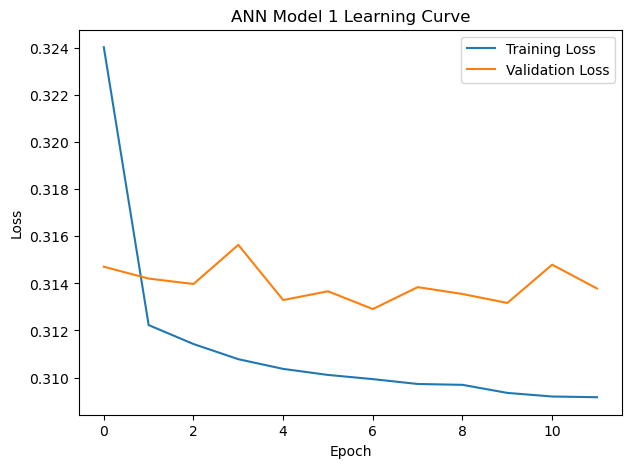

In [18]:
# 3. Learning Curve

plt.figure(figsize=(7, 5))
plt.plot(history1.history["loss"], label="Training Loss")
plt.plot(history1.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Model 1 Learning Curve")
plt.legend()
plt.show()

In [19]:
# 4. Predict Probabilities

y_prob_ann1 = ann_model1.predict(X_test_scaled).ravel()

1586/1586 ━━━━━━━━━━━━━━━━━━━━ 0s 266us/step


In [20]:
# 5. Threshold Tuning

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob_ann1 >= t).astype(int)

    threshold_results.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Recall": recall_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t),
        "F1-score": f1_score(y_test, y_pred_t)
    })

threshold_table = pd.DataFrame(threshold_results)
threshold_table.round(3)

,Threshold,Accuracy,Recall,Precision,F1-score
0,0.10,0.655,0.865,0.270,0.412
1,0.15,0.731,0.777,0.313,0.446
2,0.20,0.781,0.671,0.350,0.461
3,0.25,0.815,0.566,0.387,0.460
4,0.30,0.838,0.474,0.427,0.449
5,0.40,0.859,0.288,0.492,0.364
6,0.50,0.865,0.140,0.562,0.224


In [21]:
# 6. Threshold = 0.15

final_threshold = 0.15
y_pred_ann1 = (y_prob_ann1 >= final_threshold).astype(int)

ann1_results = {
    "Model": "ANN Model 1",
    "Architecture": "32",
    "Threshold": final_threshold,
    "Accuracy": accuracy_score(y_test, y_pred_ann1),
    "ROC AUC": roc_auc_score(y_test, y_prob_ann1),
    "PR AUC": average_precision_score(y_test, y_prob_ann1),
    "Recall": recall_score(y_test, y_pred_ann1),
    "Precision": precision_score(y_test, y_pred_ann1),
    "F1-score": f1_score(y_test, y_pred_ann1),
    "Brier Score": brier_score_loss(y_test, y_prob_ann1)
}

pd.DataFrame([ann1_results]).round(3)

,Model,Architecture,Threshold,Accuracy,ROC AUC,PR AUC,Recall,Precision,F1-score,Brier Score
0,ANN Model 1,32,0.15,0.731,0.825,0.417,0.777,0.313,0.446,0.098


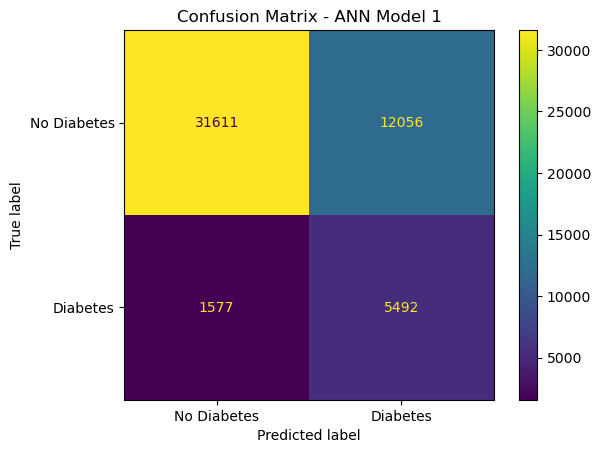

In [22]:
# 7. Confusion Matrix

cm = confusion_matrix(y_test, y_pred_ann1)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("Confusion Matrix - ANN Model 1")
plt.show()

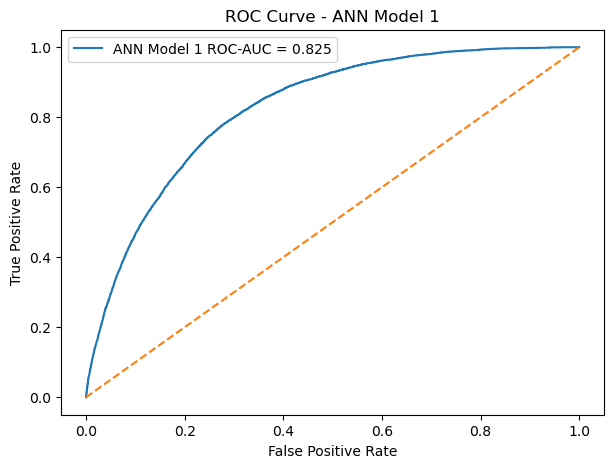

In [23]:
# 8. ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_prob_ann1)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ANN Model 1 ROC-AUC = {ann1_results['ROC AUC']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ANN Model 1")
plt.legend()
plt.show()

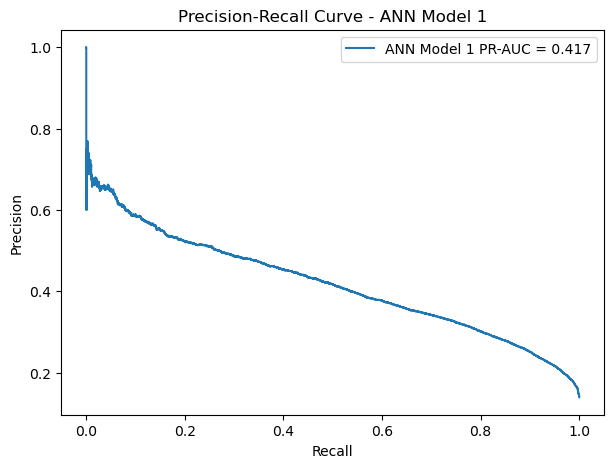

In [24]:
# 9. Precision-Recall Curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_ann1)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"ANN Model 1 PR-AUC = {ann1_results['PR AUC']:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - ANN Model 1")
plt.legend()
plt.show()

In [25]:
# 10. Model 1 Final Table

ann1_table = pd.DataFrame([ann1_results])
ann1_table.round(3)

,Model,Architecture,Threshold,Accuracy,ROC AUC,PR AUC,Recall,Precision,F1-score,Brier Score
0,ANN Model 1,32,0.15,0.731,0.825,0.417,0.777,0.313,0.446,0.098


# Model 2


In [26]:
# ANN Model 2: Deeper Architecture

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

ann_model2 = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann_model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history2 = ann_model2.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 3s 638us/step - accuracy: 0.8643 - loss: 0.3182 - val_accuracy: 0.8673 - val_loss: 0.3138
Epoch 2/50
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 2s 613us/step - accuracy: 0.8666 - loss: 0.3125 - val_accuracy: 0.8664 - val_loss: 0.3140
Epoch 3/50
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 2s 608us/step - accuracy: 0.8672 - loss: 0.3111 - val_accuracy: 0.8661 - val_loss: 0.3132
Epoch 4/50
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 2s 616us/step - accuracy: 0.8681 - loss: 0.3102 - val_accuracy: 0.8660 - val_loss: 0.3137
Epoch 5/50
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 2s 617us/step - accuracy: 0.8677 - loss: 0.3098 - val_accuracy: 0.8664 - val_loss: 0.3141
Epoch 6/50
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 2s 604us/step - accuracy: 0.8685 - loss: 0.3093 - val_accuracy: 0.8662 - val_loss: 0.3141
Epoch 7/50
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 2s 604us/step - accuracy: 0.8679 - loss: 0.3085 - val_accuracy: 0.8653 - val_loss: 0.3149
Epoch 8/50
3806/3806 ━━━━━━━━━━━━━━━━━━━━ 2s 618us/step - accuracy: 0.8689 -

In [27]:
# Predict probabilities
y_prob_ann2 = ann_model2.predict(X_test_scaled).ravel()

# Use same threshold as Model 1
threshold = 0.15
y_pred_ann2 = (y_prob_ann2 >= threshold).astype(int)

ann2_results = {
    "Model": "ANN Model 2",
    "Architecture": "64-32",
    "Threshold": threshold,
    "Accuracy": accuracy_score(y_test, y_pred_ann2),
    "ROC AUC": roc_auc_score(y_test, y_prob_ann2),
    "PR AUC": average_precision_score(y_test, y_prob_ann2),
    "Recall": recall_score(y_test, y_pred_ann2),
    "Precision": precision_score(y_test, y_pred_ann2),
    "F1-score": f1_score(y_test, y_pred_ann2),
    "Brier Score": brier_score_loss(y_test, y_prob_ann2)
}

pd.DataFrame([ann2_results]).round(3)

1586/1586 ━━━━━━━━━━━━━━━━━━━━ 0s 280us/step


,Model,Architecture,Threshold,Accuracy,ROC AUC,PR AUC,Recall,Precision,F1-score,Brier Score
0,ANN Model 2,64-32,0.15,0.724,0.826,0.417,0.79,0.308,0.443,0.098


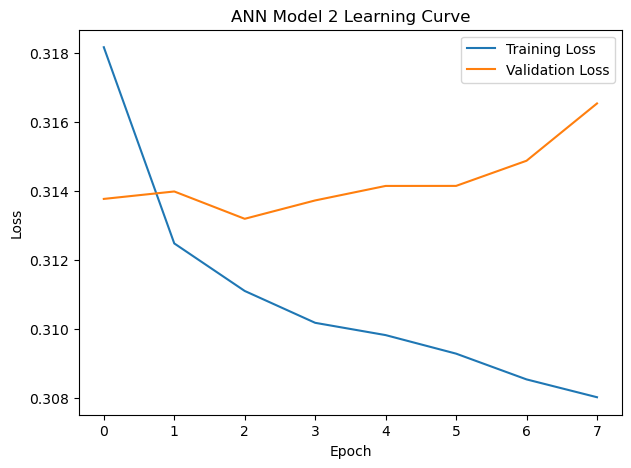

In [28]:
plt.figure(figsize=(7, 5))
plt.plot(history2.history["loss"], label="Training Loss")
plt.plot(history2.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Model 2 Learning Curve")
plt.legend()
plt.show()

## majority class baseline

In [29]:
y_pred_majority = np.zeros_like(y_test)
y_prob_majority = np.repeat(y_train.mean(), len(y_test))

majority_results = {
    "Model": "Majority Class Baseline",
    "Accuracy": accuracy_score(y_test, y_pred_majority),
    "ROC AUC": roc_auc_score(y_test, y_prob_majority),
    "PR AUC": average_precision_score(y_test, y_prob_majority),
    "Recall": recall_score(y_test, y_pred_majority, zero_division=0),
    "Precision": precision_score(y_test, y_pred_majority, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_majority, zero_division=0),
    "Brier Score": brier_score_loss(y_test, y_prob_majority)
}

pd.DataFrame([majority_results]).round(3)

,Model,Accuracy,ROC AUC,PR AUC,Recall,Precision,F1-score,Brier Score
0,Majority Class Baseline,0.861,0.5,0.139,0.0,0.0,0.0,0.12


## Keras ANN hyperparameter search

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [31]:
# ============================================================
# Keras ANN Hyperparameter Search
# ============================================================

import itertools
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    brier_score_loss
)

# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

tf.random.set_seed(42)
np.random.seed(42)


# ------------------------------------------------------------
# 2. Define Hyperparameter Search Space
# ------------------------------------------------------------

hidden_layer_options = [
    (32,),
    (64,),
    (32, 16),
    (64, 32)
]

activation_options = [
    "relu",
    "tanh",
    "sigmoid"   # logistic activation in Keras
]

learning_rate_options = [
    0.001,
    0.0001
]

# Fixed decision threshold for screening-oriented classification
threshold = 0.15

search_results = []


## Grid Search Over ANN Hyperparameters

In [32]:
best_pr_auc = -np.inf
best_model = None
best_history = None
best_params = None

search_results = []

for hidden_layers, activation, lr in itertools.product(
    hidden_layer_options,
    activation_options,
    learning_rate_options
):

    print(f"Training: layers={hidden_layers}, activation={activation}, lr={lr}")

    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],)))

    for units in hidden_layers:
        model.add(Dense(units, activation=activation))

    model.add(Dense(1, activation="sigmoid"))

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    # Validation prediction
    y_prob_val = model.predict(X_val_scaled, verbose=0).ravel()
    y_pred_val = (y_prob_val >= threshold).astype(int)

    # Validation metrics
    pr_auc_val = average_precision_score(y_val, y_prob_val)
    roc_auc_val = roc_auc_score(y_val, y_prob_val)
    recall_val = recall_score(y_val, y_pred_val)
    precision_val = precision_score(y_val, y_pred_val, zero_division=0)
    f1_val = f1_score(y_val, y_pred_val)
    brier_val = brier_score_loss(y_val, y_prob_val)
    accuracy_val = accuracy_score(y_val, y_pred_val)

    search_results.append({
        "Architecture": str(hidden_layers),
        "Activation": activation,
        "Learning Rate": lr,
        "Threshold": threshold,
        "Epochs Used": len(history.history["loss"]),
        "Val Accuracy": accuracy_val,
        "Val ROC AUC": roc_auc_val,
        "Val PR AUC": pr_auc_val,
        "Val Recall": recall_val,
        "Val Precision": precision_val,
        "Val F1-score": f1_val,
        "Val Brier Score": brier_val,
        "Final Train Loss": history.history["loss"][-1],
        "Final Val Loss": history.history["val_loss"][-1]
    })

    # Save best model based on validation PR AUC
    if pr_auc_val > best_pr_auc:
        best_pr_auc = pr_auc_val
        best_model = model
        best_history = history
        best_params = {
            "Architecture": hidden_layers,
            "Activation": activation,
            "Learning Rate": lr,
            "Validation PR AUC": pr_auc_val
        }

Training: layers=(32,), activation=relu, lr=0.001
Training: layers=(32,), activation=relu, lr=0.0001
Training: layers=(32,), activation=tanh, lr=0.001
Training: layers=(32,), activation=tanh, lr=0.0001
Training: layers=(32,), activation=sigmoid, lr=0.001
Training: layers=(32,), activation=sigmoid, lr=0.0001
Training: layers=(64,), activation=relu, lr=0.001
Training: layers=(64,), activation=relu, lr=0.0001
Training: layers=(64,), activation=tanh, lr=0.001
Training: layers=(64,), activation=tanh, lr=0.0001
Training: layers=(64,), activation=sigmoid, lr=0.001
Training: layers=(64,), activation=sigmoid, lr=0.0001
Training: layers=(32, 16), activation=relu, lr=0.001
Training: layers=(32, 16), activation=relu, lr=0.0001
Training: layers=(32, 16), activation=tanh, lr=0.001
Training: layers=(32, 16), activation=tanh, lr=0.0001
Training: layers=(32, 16), activation=sigmoid, lr=0.001
Training: layers=(32, 16), activation=sigmoid, lr=0.0001
Training: layers=(64, 32), activation=relu, lr=0.001
Tr

In [33]:
keras_grid_results = pd.DataFrame(search_results)

keras_grid_results.sort_values(
    by="Val PR AUC",
    ascending=False
).round(3)

,Architecture,Activation,Learning Rate,Threshold,Epochs Used,Val Accuracy,Val ROC AUC,Val PR AUC,Val Recall,Val Precision,Val F1-score,Val Brier Score,Final Train Loss,Final Val Loss
4,"(32,)",sigmoid,0.001,0.15,24,0.735,0.828,0.434,0.768,0.315,0.446,0.097,0.309,0.313
21,"(64, 32)",tanh,0.000,0.15,34,0.738,0.828,0.433,0.762,0.317,0.448,0.097,0.308,0.314
11,"(64,)",sigmoid,0.000,0.15,50,0.739,0.828,0.433,0.763,0.318,0.449,0.097,0.311,0.313
23,"(64, 32)",sigmoid,0.000,0.15,50,0.736,0.828,0.433,0.767,0.316,0.447,0.097,0.310,0.313
16,"(32, 16)",sigmoid,0.001,0.15,19,0.733,0.828,0.433,0.775,0.314,0.447,0.097,0.309,0.314
17,"(32, 16)",sigmoid,0.000,0.15,50,0.737,0.828,0.433,0.765,0.316,0.448,0.097,0.311,0.313
22,"(64, 32)",sigmoid,0.001,0.15,15,0.731,0.828,0.432,0.778,0.313,0.446,0.097,0.309,0.314
10,"(64,)",sigmoid,0.001,0.15,17,0.734,0.828,0.432,0.771,0.315,0.447,0.097,0.309,0.314
1,"(32,)",relu,0.000,0.15,50,0.737,0.828,0.432,0.770,0.317,0.449,0.097,0.309,0.313
5,"(32,)",sigmoid,0.000,0.15,50,0.739,0.828,0.431,0.762,0.318,0.449,0.097,0.311,0.314


In [37]:
hyperparameter_table = keras_grid_results[
    [
        "Architecture",
        "Activation",
        "Learning Rate",
        "Epochs Used",
        "Val PR AUC",
        "Val ROC AUC",
        "Val Recall",
        "Val Precision",
        "Val F1-score",
        "Val Brier Score"
    ]
].head(6)

hyperparameter_table

,Architecture,Activation,Learning Rate,Epochs Used,Val PR AUC,Val ROC AUC,Val Recall,Val Precision,Val F1-score,Val Brier Score
0,"(32,)",relu,0.0010,14,0.429325,0.827323,0.768284,0.313568,0.445365,0.097078
1,"(32,)",relu,0.0001,50,0.432031,0.828114,0.769840,0.317262,0.449344,0.096860
2,"(32,)",tanh,0.0010,14,0.428985,0.827273,0.762626,0.318919,0.449756,0.097140
3,"(32,)",tanh,0.0001,50,0.428038,0.827381,0.758099,0.317082,0.447142,0.097140
4,"(32,)",sigmoid,0.0010,24,0.433654,0.828151,0.767718,0.314627,0.446336,0.096791
5,"(32,)",sigmoid,0.0001,50,0.430535,0.827923,0.761777,0.317981,0.448675,0.096951


## Evaluate best model

In [34]:
y_prob_test = best_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_test = (y_prob_test >= threshold).astype(int)

optimized_ann_test_result = {
    "Model": "Optimized ANN",
    "Architecture": str(best_params["Architecture"]),
    "Activation": best_params["Activation"],
    "Learning Rate": best_params["Learning Rate"],
    "Threshold": threshold,
    "Test Accuracy": accuracy_score(y_test, y_pred_test),
    "Test ROC AUC": roc_auc_score(y_test, y_prob_test),
    "Test PR AUC": average_precision_score(y_test, y_prob_test),
    "Test Recall": recall_score(y_test, y_pred_test),
    "Test Precision": precision_score(y_test, y_pred_test, zero_division=0),
    "Test F1-score": f1_score(y_test, y_pred_test),
    "Test Brier Score": brier_score_loss(y_test, y_prob_test)
}

pd.DataFrame([optimized_ann_test_result]).round(3)

,Model,Architecture,Activation,Learning Rate,Threshold,Test Accuracy,Test ROC AUC,Test PR AUC,Test Recall,Test Precision,Test F1-score,Test Brier Score
0,Optimized ANN,"(32,)",sigmoid,0.001,0.15,0.736,0.826,0.419,0.774,0.316,0.449,0.098
